# Evaluate different K values

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.getcwd()
os.chdir('..')

CPU times: user 651 ms, sys: 512 ms, total: 1.16 s
Wall time: 8min 32s


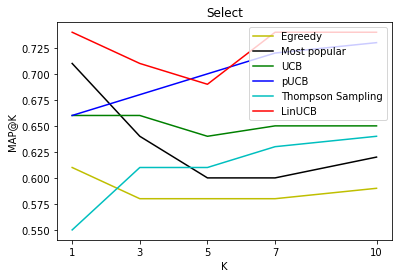

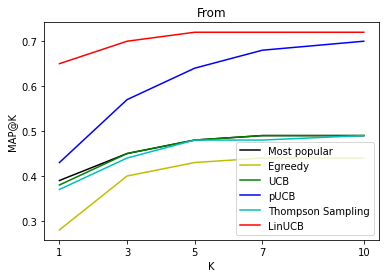

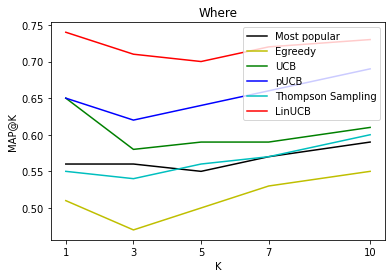

In [11]:
%%time
from sqlcompletions.evaluator import run_plot_parameter, create_tests
from sqlcompletions.sqlparser import schema


clauses_to_test = [0, 1, 2]
k_to_test = {1: 1, 3:3, 5:5, 7:7,10:10 }



db = schema()
results = []
for clause in clauses_to_test:
    tests = []
    for k in k_to_test:
        add_tests = create_tests(algorithms= ["egreedy","thompson", "ucb", "pucb", "linucb", "popular"], clause=clause, top_k = k , db = db )
        for test in add_tests: # add common
            test.update({
                'parameter_value': k
            })
        
        tests += add_tests

    results.append(run_plot_parameter(tests, parameter_name = "K", param_map = k_to_test).results)

## SELECT

In [12]:
results[0]

,Algorithm,1,3,5,7,10
0,Egreedy,0.61,0.58,0.58,0.58,0.59
1,Most popular,0.71,0.64,0.60,0.60,0.62
2,UCB,0.66,0.66,0.64,0.65,0.65
3,pUCB,0.66,0.68,0.70,0.72,0.73
4,Thompson Sampling,0.55,0.61,0.61,0.63,0.64
5,LinUCB,0.74,0.71,0.69,0.74,0.74


## FROM

In [13]:
results[1]

,Algorithm,1,3,5,7,10
0,Most popular,0.39,0.45,0.48,0.49,0.49
1,Egreedy,0.28,0.40,0.43,0.44,0.44
2,UCB,0.38,0.45,0.48,0.49,0.49
3,pUCB,0.43,0.57,0.64,0.68,0.70
4,Thompson Sampling,0.37,0.44,0.48,0.48,0.49
5,LinUCB,0.65,0.70,0.72,0.72,0.72


## WHERE

In [14]:
results[2]

,Algorithm,1,3,5,7,10
0,Most popular,0.56,0.56,0.55,0.57,0.59
1,Egreedy,0.51,0.47,0.50,0.53,0.55
2,UCB,0.65,0.58,0.59,0.59,0.61
3,pUCB,0.65,0.62,0.64,0.66,0.69
4,Thompson Sampling,0.55,0.54,0.56,0.57,0.60
5,LinUCB,0.74,0.71,0.70,0.72,0.73
